In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "mall_customers_dataset" / "Mall_Customers.csv"
df = pd.read_csv(train_path)

In [3]:
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]
X_scaled = StandardScaler().fit_transform(X)
ks, inertias, silhouettes = [], [], []

for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ks.append(k)
    inertias.append(model.inertia_)
    silhouettes.append(sil)
    print("k=", k, "inertia=", round(model.inertia_, 2),
        "silhouette=", round(sil, 3))

k= 2 inertia= 389.39 silhouette= 0.335
k= 3 inertia= 295.21 silhouette= 0.358
k= 4 inertia= 205.23 silhouette= 0.404
k= 5 inertia= 168.25 silhouette= 0.417
k= 6 inertia= 133.87 silhouette= 0.427
k= 7 inertia= 117.01 silhouette= 0.417
k= 8 inertia= 103.83 silhouette= 0.409


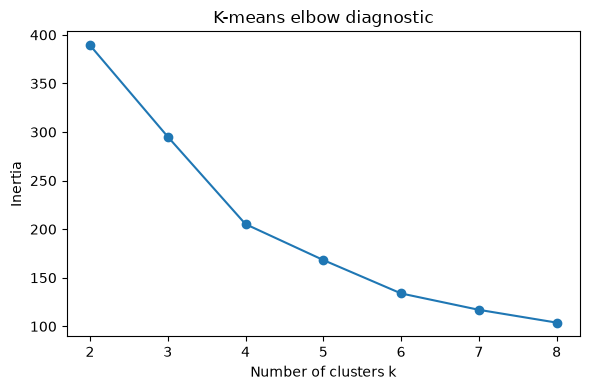

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(ks, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("K-means elbow diagnostic")
plt.tight_layout()
plt.show()

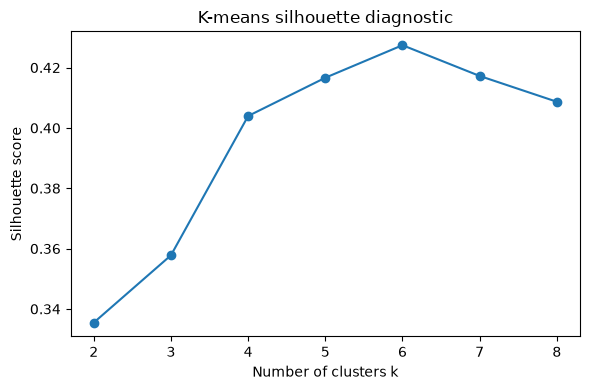

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(ks, silhouettes, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("K-means silhouette diagnostic")
plt.tight_layout()
plt.show()